Best Model: Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])
Accuracy: 0.78708303761533
Model saved successfully!

TASK 2 - MODEL RESULTS

Best Model Used:
Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('nu

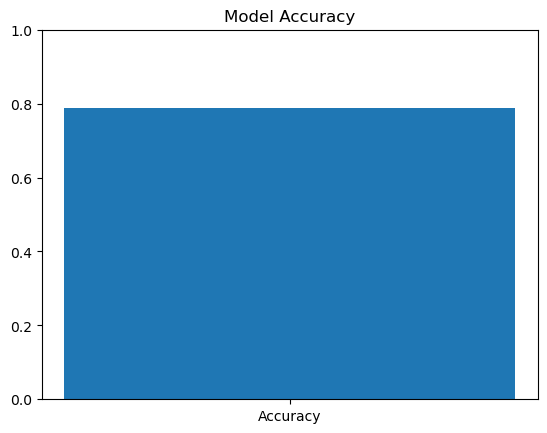

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib

# Load dataset (you must download Telco Churn CSV from Kaggle)
df = pd.read_csv("Churn.csv")

# Drop customerID if exists
if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)

# Convert target column
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Split features/target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Identify numeric and categorical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

# Preprocessing
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

# Pipeline
pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Hyperparameter tuning
param_grid = {
    "classifier": [LogisticRegression(max_iter=1000), RandomForestClassifier()],
}

grid = GridSearchCV(pipe, param_grid, cv=3, scoring="accuracy")
grid.fit(X_train, y_train)

# Predictions
y_pred = grid.predict(X_test)

print("Best Model:", grid.best_estimator_)
print("Accuracy:", accuracy_score(y_test, y_pred))

# Save pipeline
joblib.dump(grid.best_estimator_, "churn_pipeline.pkl")

print("Model saved successfully!")
import pandas as pd
df = pd.read_csv("Churn.csv")
# =========================
# FINAL RESULTS DISPLAY
# =========================

print("\n==============================")
print("TASK 2 - MODEL RESULTS")
print("==============================\n")

# Best model
print("Best Model Used:")
print(grid.best_estimator_)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", round(accuracy, 4))

# If GridSearchCV exists
print("\nBest Parameters:")
print(grid.best_params_)

print("\n==============================")
print("SAMPLE PREDICTIONS")
print("==============================")

# Show some predictions
for i in range(5):
    print(f"Actual: {y_test.iloc[i]} | Predicted: {y_pred[i]}")
    import matplotlib.pyplot as plt
import numpy as np

# Accuracy visualization (simple)
labels = ['Accuracy']
values = [accuracy]

plt.bar(labels, values)
plt.ylim(0, 1)
plt.title("Model Accuracy")
plt.show()